## ReLU MLP Single-Seed Learning Dynamics

This notebook runs a standard fully connected ReLU network with a single training phase.

It focuses on one seed to inspect learning dynamics clearly (checkpoints, scatter alignment, and start/end metrics).

No dropout, normalization, or multi-phase logic is used.

In [5]:
from pathlib import Path

from itables import show
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from layer_lenses.odt import samples_reaching_node
from layer_lenses.relu_analysis import (
    collect_start_end_metrics,
    first_layer_odt_alignment,
    masked_accuracy_by_odt_leaf,
    neuron_leaf_responsibility_from_ablation,
    plot_first_layer_odt_alignment,
    plot_layered_relu_graph,
    quadratic_snapshot_epochs,
    run_single_relu_seed,
    summarize_neuron_responsibility,
)
from layer_lenses.relu_training import checkpoint_model_from_state

# Scratch-aligned defaults with a plain ReLU MLP.
DIM = 100
DEPTH = 5
N_TRAIN = 80_000
HIDDEN_DIMS = [40, 40, 40]

TOTAL_EPOCHS = 2000
LR = 2e-3
BATCH_SIZE = 80
WEIGHT_DECAY = 0.01

SNAPSHOT_EPOCHS = range(TOTAL_EPOCHS)
print(f"Using {len(SNAPSHOT_EPOCHS)} snapshot epochs.")

SEED = 5178

seed_result = None

Using 2000 snapshot epochs.


## Run selected seed

This is the expensive cell. It runs single-phase ReLU MLP training for the selected seed.

In [6]:
print(f"Running seed {SEED} ...")
seed_result = run_single_relu_seed(
    SEED,
    dim=DIM,
    depth=DEPTH,
    n_train=N_TRAIN,
    hidden_dims=HIDDEN_DIMS,
    total_epochs=TOTAL_EPOCHS,
    lr=LR,
    batch_size=BATCH_SIZE,
    weight_decay=WEIGHT_DECAY,
    snapshot_epochs=SNAPSHOT_EPOCHS,
)
print("Done")

Running seed 5178 ...


Training ReLU MLP:   0%|          | 0/2001 [00:00<?, ?it/s]

Done


## Scatter plot and gating dynamics analysis

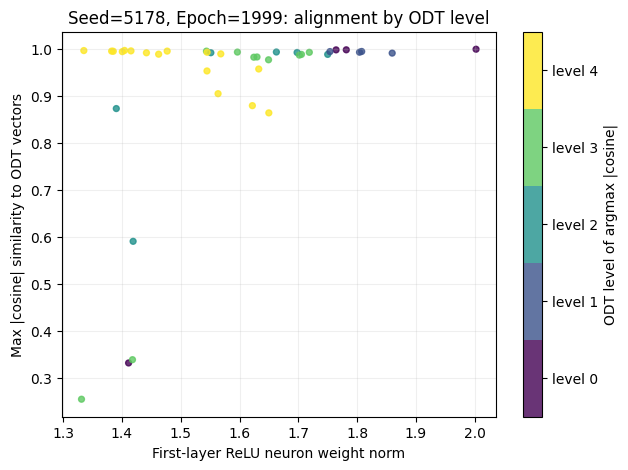

In [7]:
out = seed_result["out"]
ckpts = out["checkpoint_snapshots"]
tree = seed_result["tree"]
EPOCH = list(ckpts.keys())[-1]  # choose from available checkpoints

alignment, ax = plot_first_layer_odt_alignment(
    state_dict=ckpts[EPOCH],
    tree=tree,
    depth=DEPTH,
    epoch=EPOCH,
    seed=SEED,
)
plt.show()

# Keep these names available for downstream scratch cells.
first_layer_wts = alignment["first_layer_wts"]
odt_wts = alignment["odt_wts"]
row_norms = alignment["row_norms"]
cos = alignment["cos"]
abs_cos = alignment["abs_cos"]
max_abs_cos = alignment["max_abs_cos"]
closest_odt = alignment["closest_odt"]
closest_odt_np = alignment["closest_odt_np"]
node_level = alignment["node_level"]

## Visualise neural net as graph

Visible edges: 74 / 3240
First-layer aligned nodes: 37 / 40


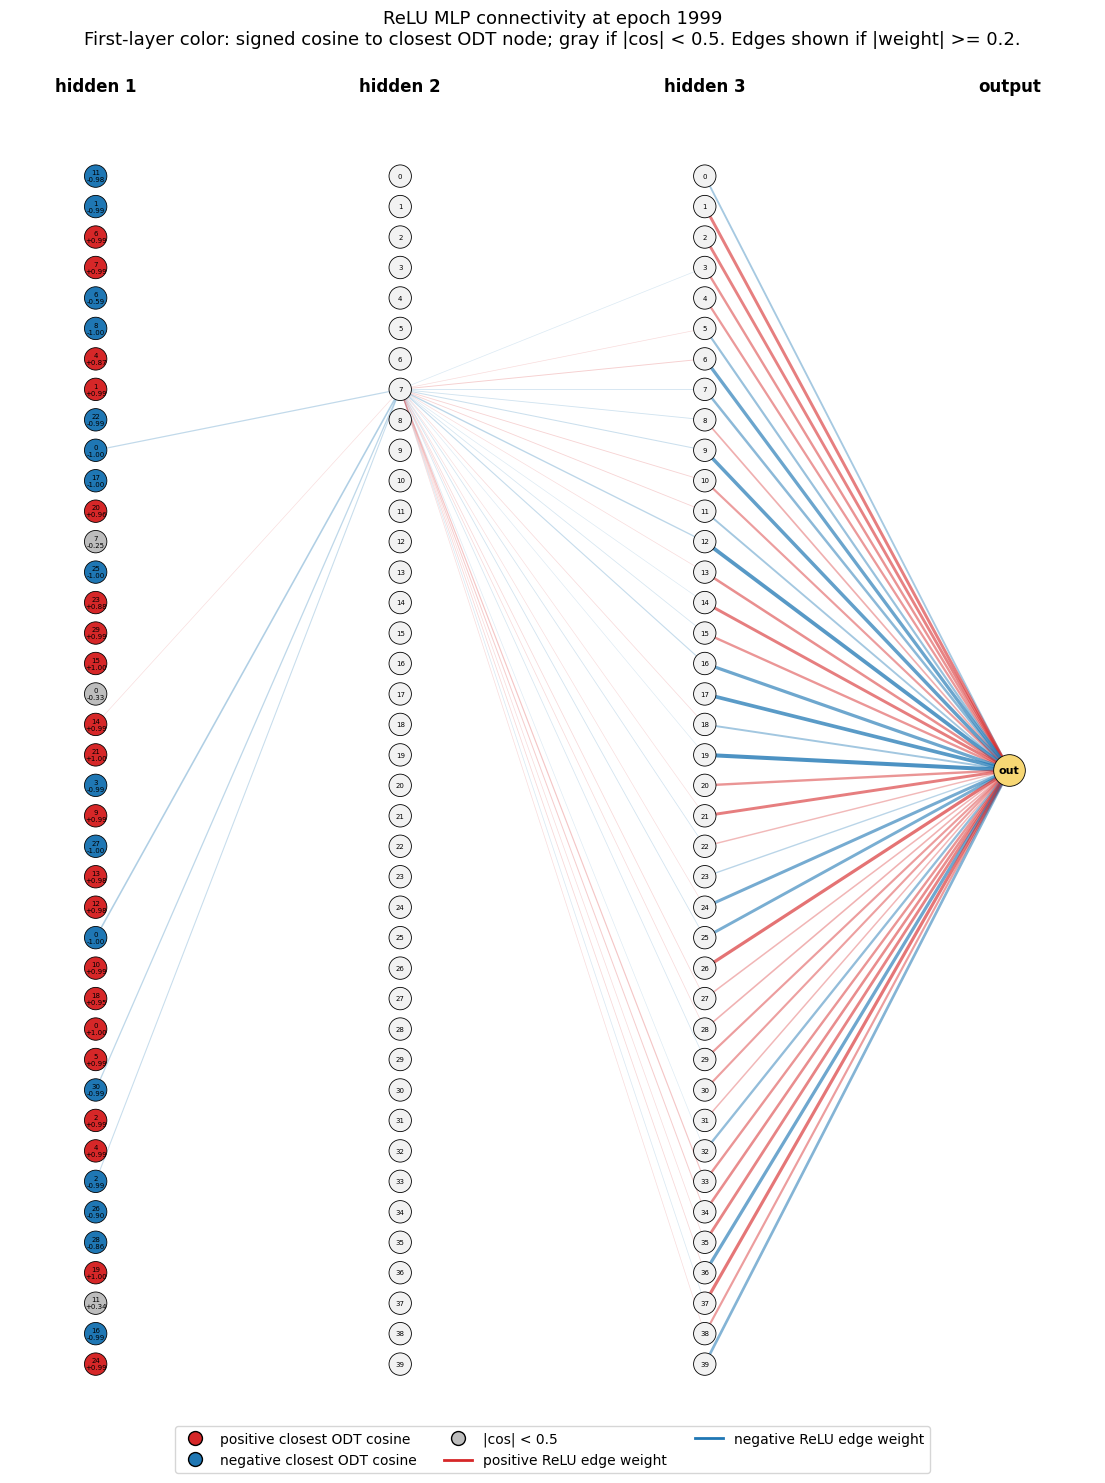

In [8]:
# Layered ReLU graph at a chosen snapshot epoch.
GRAPH_EPOCH = EPOCH
ALIGNMENT_ABS_THRESHOLD = 0.5
EDGE_ABS_THRESHOLD = 0.20  # tune this; increase if graph is too dense
FIGSIZE = (14, 18)
NODE_MASK = np.zeros((40, 3), dtype=bool)
NODE_MASK[:, 0] = True
NODE_MASK[7, 1] = True
NODE_MASK[:, 2] = True

state = ckpts[GRAPH_EPOCH]
W0 = state["hidden_layers.0.weight"].detach().cpu()
W1 = state["hidden_layers.1.weight"].detach().cpu()
W2 = state["hidden_layers.2.weight"].detach().cpu()
Wout = state["output_layer.weight"].detach().cpu()

graph_alignment, visible_edges, graph_fig, graph_ax = plot_layered_relu_graph(
    state_dict=state,
    tree=tree,
    depth=DEPTH,
    epoch=GRAPH_EPOCH,
    node_mask=NODE_MASK,
    alignment_abs_threshold=ALIGNMENT_ABS_THRESHOLD,
    edge_abs_threshold=EDGE_ABS_THRESHOLD,
    figsize=FIGSIZE,
    require_both_edge_endpoints_selected=True,
)
plt.show()

## Computing neuron responsibilities -- i.e. log loss changes to data entering leaf nodes on neuron removal

In [9]:
checkpoint_model = checkpoint_model_from_state(seed_result["out"]["model"], ckpts[EPOCH])
base_node_mask = np.ones((40, 3), dtype=int)

neuron_responsibility, neuron_responsibility_df, baseline_leaf_metrics = (
    neuron_leaf_responsibility_from_ablation(
        model=checkpoint_model,
        x_eval=seed_result["data"]["x_eval"],
        y_eval=seed_result["data"]["y_eval"],
        tree=seed_result["tree"],
        base_node_mask=base_node_mask,
        min_log_loss_delta=0.2,
        min_relative_log_loss_delta=None,
        min_accuracy_drop=None,
    )
)
neuron_summary = summarize_neuron_responsibility(neuron_responsibility)


In [ ]:

show(
    neuron_summary,
    scrollY="500px",
    scrollX=True,
    search=True,
    paging=True,
    pageLength=25,
)

In [14]:
checkpoint_model = checkpoint_model_from_state(seed_result["out"]["model"], ckpts[EPOCH])

# Shape (40, 3): 1 keeps a hidden node, 0 masks it out.
node_mask = np.ones((40, 3), dtype=int)
node_mask[:, 1] = 0
node_mask[5, 1] = 1
# second hidden layer neuron : ODT node responsibilities
# 0: [49], 4: [46], 5: [50,51,52,53,54], 6: [39], 7:[62], 9:[36], 10 : [55, 56, 57, 58]

leaf_accuracy = masked_accuracy_by_odt_leaf(
    model=checkpoint_model,
    node_mask=node_mask,
    x_eval=seed_result["data"]["x_eval"],
    y_eval=seed_result["data"]["y_eval"],
    tree=seed_result["tree"],
)

display(leaf_accuracy)
print("Overall masked accuracy:", np.average(leaf_accuracy["accuracy"], weights=leaf_accuracy["num_samples"]))

,leaf_node,leaf_index,true_label,num_samples,num_correct,accuracy,mean_log_loss,mean_logit,mean_abs_logit
0,31,0,-1,2515,102,0.040557,0.670883,-0.119859,0.119859
1,32,1,1,2487,2384,0.958585,0.772779,-0.101478,0.101478
2,33,2,-1,2541,109,0.042896,0.669618,-0.122790,0.122790
3,34,3,1,2549,2439,0.956846,0.778479,-0.107710,0.107710
4,35,4,-1,2611,102,0.039065,0.672776,-0.098455,0.098455
5,36,5,1,2495,2406,0.964329,0.746534,-0.070269,0.070269
6,37,6,-1,2496,106,0.042468,0.672499,-0.094658,0.094658
7,38,7,1,2462,2369,0.962226,0.767727,-0.093806,0.093806
8,39,8,-1,2500,70,0.028000,0.679528,-0.058391,0.058391
9,40,9,1,2541,2463,0.969303,0.747000,-0.069344,0.069344


Overall masked accuracy: 0.50015


## Neuron activity breakdown -- neuron activity based on data entering ODT leaf nodes 

In [ ]:
from layer_lenses.relu_analysis import count_active_points_for_neuron_leaf

checkpoint_model = checkpoint_model_from_state(seed_result["out"]["model"], ckpts[EPOCH])
leaf_node_ids = list(range((2 ** DEPTH) - 1, (2 ** (DEPTH + 1)) - 1))

hidden_widths = [layer.out_features for layer in checkpoint_model.hidden_layers]
total_hidden_neurons = sum(hidden_widths)

neuron_leaf_activity_rows = []
for neuron_global_id in range(total_hidden_neurons):
    for leaf_node_id in leaf_node_ids:
        neuron_leaf_activity_rows.append(
            count_active_points_for_neuron_leaf(
                model=checkpoint_model,
                neuron_id=neuron_global_id,
                leaf_node_id=leaf_node_id,
                x_eval=seed_result["data"]["x_eval"],
                tree=seed_result["tree"],
            )
        )

neuron_leaf_activity_summary = pd.DataFrame(neuron_leaf_activity_rows)

# display(neuron_leaf_activity_summary)
# show(
#     neuron_leaf_activity_summary,
#     scrollY="500px",
#     scrollX=True,
#     search=True,
#     paging=True,
#     pageLength=25,
# )

In [13]:
# Build: neuron -> activity vector over ODT leaves
# Input: neuron_leaf_activity_summary (DataFrame from earlier cell)
# Output: neuron_to_leaf_activity (dict)

import numpy as np

df = neuron_leaf_activity_summary.copy()

# Ensure deterministic leaf ordering (e.g., 31..62)
leaf_ids = np.sort(df["leaf_node_id"].unique())
leaf_id_to_pos = {leaf_id: i for i, leaf_id in enumerate(leaf_ids)}

# Choose neuron key style:
# Option A: global neuron id only
# neuron_keys = sorted(df["global_neuron_id"].unique())

# Option B: (layer, local_neuron_id) tuple
neuron_keys = sorted(
    {(int(r.layer), int(r.local_neuron_id)) for r in df[["layer", "local_neuron_id"]].itertuples(index=False)}
)

neuron_to_leaf_activity = {}

for neuron_key in neuron_keys:
    vec = np.zeros(len(leaf_ids), dtype=np.int64)

    if isinstance(neuron_key, tuple):
        layer, local_id = neuron_key
        sub = df[(df["layer"] == layer) & (df["local_neuron_id"] == local_id)]
    else:
        sub = df[df["global_neuron_id"] == neuron_key]

    for row in sub.itertuples(index=False):
        pos = leaf_id_to_pos[int(row.leaf_node_id)]
        vec[pos] = int(row.active_points_in_leaf)

    neuron_to_leaf_activity[neuron_key] = vec

# Optional: keep leaf order metadata for downstream use
neuron_activity_leaf_order = leaf_ids

print(f"Built dictionary for {len(neuron_to_leaf_activity)} neurons.")
print(f"Vector length per neuron: {len(neuron_activity_leaf_order)} leaves")
print("Example key:", next(iter(neuron_to_leaf_activity)))
print("Example vector:", neuron_to_leaf_activity[next(iter(neuron_to_leaf_activity))])

Built dictionary for 120 neurons.
Vector length per neuron: 32 leaves
Example key: (0, 0)
Example vector: [1195 1133 1181 1186 1209 1171 1227 1111 1129 1163 1134 1142 1136 1136
 1147 1158 2550 2521  406  459 1480 1352 1404 1412 1225 1270 1194 1211
 1239 1250 1234 1317]


In [22]:
neuron_to_leaf_activity[(1,7)]

array([  45,   43,   50,   48,   51,   43,   43,   50,   28,   36,   40,
         43,   44,   37,   38,   48,  182,  187,  159,  199,  164,  193,
        237,  193, 1416, 1358, 1435, 1458, 1383, 1468,  256, 2603])

## Start/end metrics

This block computes start/end metrics for the selected seed.

In [15]:
if seed_result is None:
    raise ValueError("Run the training cell first to populate seed_result.")

rows = collect_start_end_metrics(seed_result)
metrics_table = pd.DataFrame(rows).sort_values(["timepoint"]).reset_index(drop=True)
display(metrics_table)

,timepoint,epoch,train_log_loss,test_error
0,end,1999,0.016431,0.043887
1,start,0,0.693116,0.499038


## Quick visualization

Bar plots for start vs end test error and train log loss for the selected seed.

In [ ]:
if seed_result is None:
    raise ValueError("Run the training cell first to populate seed_result.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(metrics_table["timepoint"], metrics_table["test_error"])
axes[0].set_title("Test error")

axes[1].bar(metrics_table["timepoint"], metrics_table["train_log_loss"])
axes[1].set_title("Train log loss")

plt.tight_layout()
plt.show()